# Description

In this notebook, I will quantization matrix from FP32 -> INT8

In [1]:
import os 
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
devive = 'cpu'

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA RTX A5000


In [3]:
N = 1024
A = torch.randn(N, N, device=devive)
print(f"Shape of A: {A.shape}, dtype: {A.dtype}")
print(f"Max value: {A.max().item()}")
print(f"Min value: {A.min().item()}")

Shape of A: torch.Size([1024, 1024]), dtype: torch.float32
Max value: 4.804582595825195
Min value: -5.019196510314941


In [4]:
def quantize_tensor_int8(mat):
    min_val = mat.min()
    max_val = mat.max()
    
    qmin = -128
    qmax = 127
    scale = (max_val - min_val) / (qmax - qmin)
    zero_point = qmin - torch.round(min_val / scale).item()
    
    q_mat = torch.clamp(torch.round(mat / scale) + zero_point, qmin, qmax).to(torch.int8)
    return q_mat, scale, zero_point

def dequantize_tensor_int8(q_mat, scale:float, zero_point:float):
    return scale * (q_mat.float() - zero_point)

def quantization_error(original, dequantized):
    """
    Compute the relative error between the original and dequantized tensors using l2 norm.
    """
    return torch.norm(original - dequantized) / torch.norm(original)

In [5]:
A_quant, scale, zero_point = quantize_tensor_int8(A)
print(f"Quantized A: {A_quant.shape}")
print(f"Dtype: {A_quant.dtype}")
print(f"Scale: {scale}")
print(f"Zero Point: {zero_point}")

Quantized A: torch.Size([1024, 1024])
Dtype: torch.int8
Scale: 0.03852462396025658
Zero Point: 2.0


In [6]:
A_dequant = dequantize_tensor_int8(A_quant, scale, zero_point)
error = quantization_error(A, A_dequant)
print(f"Quantization Relative Error (l2 norm): {error.item()}")

Quantization Relative Error (l2 norm): 0.011113199405372143


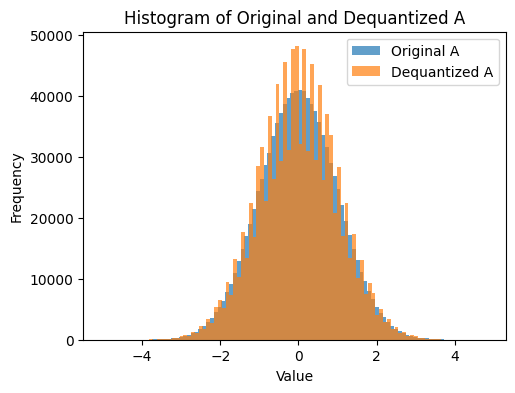

In [7]:
# plot histogram of A and A_dequant
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(A.cpu().numpy().flatten(), bins=100, alpha=0.7, label='Original A')
plt.hist(A_dequant.cpu().numpy().flatten(), bins=100, alpha=0.7, label='Dequantized A')
plt.title('Histogram of Original and Dequantized A')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()    